# TAREA 4
Maria Fernanda Gómez Flores    
Lunes 28 de septiembre 2026

Realiza un análisis para un portafolio compuesto por los siguientes activos: **LLY (Eli Lilly), NVDA (NVIDIA), MSFT (Microsoft) y KXI (iShares Global Consumer Staples ETF)**

1.- Descarga los precios de cierre ajustado para los activos desde el 2018-01-01 hasta hoy, calcula los rendimientos diarios, así como el rendimiento promedio, la volatilidad de cada activo y la matriz de covarianza

2.- Utilizando la matriz de covarianza de los activos, optimiza los pesos para obtener el portafolio de mínima varianza. Calcula su rendimiento y volatilidad y define claramente el peso especifico que cada acción tendría dentro del portafolio

3.- Obtén el portafolio que maximiza el ratio de Sharpe, calcula su rendimiento y volatilidad. Asume una tasa libre de riesgo del 4% anual y define claramente el peso especifico que cada acción tendría dentro del portafolio

4.- Asume otro portafolio equitativamente ponderado y calcula su rendimiento promedio y su volatilidad

5.- Grafica la frontera eficiente en términos de media-varianza junto con los portafolios eficientes, el portafolio equitativamente ponderado y los activos individuales

6.- Compara en un solo dataframe las métricas de rendimiento y volatilidad de los tres portafolios y concluye sobre riesgo, riesgo-rendimiento, frontera eficiente, ponderaciones y estrategia cuantitativa contra feeling

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [2]:
tickers=['LLY','NVDA','MSFT','KXI']
prices=yf.download(tickers,start='2018-01-01',end='2026-09-29')['Close']
rets=(prices/prices.shift()-1).dropna()
rets
rf=0.04

/var/folders/x9/60hcc2ln62d3r3xyv90d3wl40000gn/T/ipykernel_49464/1501777537.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices=yf.download(tickers,start='2018-01-01',end='2026-09-29')['Close']
[*********************100%***********************]  4 of 4 completed


## 1. RENDIMIENTO Y VOLATILIDAD DE LOS ACTIVOS

**LLY - Eli Lilly:** es una empresa del sector salud enfocada principalmente en medicamentos

**NVDA - NVIDIA:** pertenece al sector tecnología y se enfoca principalmente en semiconductores y procesamiento computacional

**MSFT - Microsoft:** también pertenece a tecnología pero su negocio está más diversificado entre software nube y otros servicios

**KXI - iShares Global Consumer Staples ETF:** es un ETF de consumo básico que agrupa empresas globales de este sector

Puedo esperar que no todos se comporten igual porque dependen de sectores y factores diferentes.

In [3]:
mean=rets.mean()
mean

Ticker
KXI     0.000244
LLY     0.001459
MSFT    0.001020
NVDA    0.002253
dtype: float64

In [4]:
std=rets.std()
std

Ticker
KXI     0.009109
LLY     0.020060
MSFT    0.018342
NVDA    0.031702
dtype: float64

In [5]:
cov=rets.cov()
cov

Ticker,KXI,LLY,MSFT,NVDA
Ticker,,,,
KXI,0.000083,0.000070,0.000080,0.000087
LLY,0.000070,0.000402,0.000101,0.000130
MSFT,0.000080,0.000101,0.000336,0.000360
NVDA,0.000087,0.000130,0.000360,0.001005


In [6]:
annual_mean=mean*252
annual_volatility=std*np.sqrt(252)

results_assets=pd.DataFrame({
    'Rendimiento anual': annual_mean*100,
    'Volatilidad anual': annual_volatility*100
})

results_assets

,Rendimiento anual,Volatilidad anual
Ticker,,
KXI,6.136694,14.460729
LLY,36.756516,31.844785
MSFT,25.693818,29.117648
NVDA,56.765559,50.325022


Con los resultados puedo ver que NVDA fue el activo con mayor rendimiento anual con 56.77% pero también fue por mucho el más volátil con 50.33%

LLY también tuvo un rendimiento bastante alto de 36.76% con una volatilidad de 31.84% y MSFT tuvo un rendimiento de 25.69% con una volatilidad de 29.12%

Por otro lado KXI fue el activo más estable con una volatilidad de 14.46% aunque también tuvo el rendimiento más bajo con 6.14%

Entonces aquí no solamente importa ver cuál rindió más. NVDA dio el mayor rendimiento pero también tuvo mucho más riesgo y KXI fue mucho más estable aunque su rendimiento fue bastante menor

La matriz de covarianza también es importante porque para armar el portafolio no basta con ver cada activo por separado. También importa cómo se mueven entre ellos y eso es justo lo que usa la optimización

## 2. PORTAFOLIO DE MÍNIMA VARIANZA

In [7]:
# Definir funcion objetivo
#def var(w):
#    return w.T @ cov @ w 

var = lambda w: w.T @ cov @ w

In [8]:
# Definir valores iniciales

# w_inicial = [0.25, 0.25, 0.25, 0.25] # Equa wight
## hacer los pesos equitativos de forma automatica segun el numero de activos que tengo. 
n_assets = len(prices.columns)

w_inicial = np.ones(n_assets) / n_assets

In [9]:
# Definir las cotas
cotas = [(0,1)] * n_assets

In [10]:
# Definir las restricciones
restr = lambda w: sum(w) -1

In [11]:
# Definir tolerancia
np.random.seed(42)
tol = 1e-32

In [12]:
# Aplicar función de scipy.optimize
results = minimize(fun=var, x0=w_inicial, bounds=cotas, tol=tol, 
         constraints={"fun": restr, "type": "eq"})

results

 message: Optimization terminated successfully
 success: True
  status: 0
     fun: 8.249626931453921e-05
       x: [ 9.578e-01  3.665e-02  5.549e-03  1.643e-18]
     nit: 23
     jac: [ 1.650e-04  1.650e-04  1.650e-04  1.808e-04]
    nfev: 130
    njev: 23

In [13]:
# encontrar pesos optimos: 
w_min_var = results.x
dict(zip(prices.columns, w_min_var))

{'KXI': np.float64(0.9578029265224118),
 'LLY': np.float64(0.036648168758718305),
 'MSFT': np.float64(0.005548904718869764),
 'NVDA': np.float64(1.6429638412588434e-18)}

In [14]:
# Obtener rendimiento del portafolio
R_min_var = sum(w_min_var * mean)
R_min_var * 100 * 252

7.3673750813703105

In [15]:
# Obtener volatilidad del portafolio
vol_min_var = np.sqrt(w_min_var.T @ cov @ w_min_var)
vol_min_var * np.sqrt(252) * 100

np.float64(14.418411794391183)

In [16]:
pesos_min_var=pd.DataFrame({
    'Activo':prices.columns,
    'Peso':w_min_var*100
})

pesos_min_var

,Activo,Peso
0,KXI,9.578029e+01
1,LLY,3.664817e+00
2,MSFT,5.548905e-01
3,NVDA,1.642964e-16


En mínima varianza casi todo el peso se fue a KXI con 95.78% después LLY con 3.66% y MSFT con 0.55% mientras que NVDA quedó prácticamente en 0%

Esto tiene bastante sentido porque KXI fue el activo con menor volatilidad individual con 14.46% y NVDA fue el más volátil con 50.33%

El portafolio terminó con un rendimiento anual de 7.37% y una volatilidad anual de 14.42%. Entonces si lo que quiero es bajar el riesgo lo más posible este portafolio cumple justo con ese objetivo

Algo importante es que los pesos no salen solamente de ver cuál activo tiene menos volatilidad. También entra la covarianza porque el método toma en cuenta cómo se combinan todos para reducir la varianza total

## 3. PORTAFOLIO DE MÁXIMO SHARPE

In [17]:
def opt_max_sharpe(price: pd.DataFrame, rf: float):

    # Inputs
    rets = price.pct_change().dropna()
    cov = rets.cov()
    mu = rets.mean()

    # Funcion
    sharpe = lambda w: -((sum(w*mu)-rf)/np.sqrt(w.T@cov@w))

    # Restricciones
    restr = lambda w: sum(w) - 1

    # Valor Inicial
    n_assets = len(price.columns)
    w_0 = np.ones(n_assets) / n_assets

    # tol
    tol = 1e-32

    # Rangos
    rangos = [(0,1)] * n_assets

    # optimización
    results = minimize(fun=sharpe,x0=w_0,bounds=rangos,constraints={'fun': restr, 'type': 'eq'},tol=tol)

    return results.x

In [18]:
# Obtener los pesos
w_max_sharpe=opt_max_sharpe(prices, 0.04/252)
dict(zip(prices.columns, w_max_sharpe))

{'KXI': np.float64(2.4167406832119073e-17),
 'LLY': np.float64(0.6055587399464551),
 'MSFT': np.float64(2.3498233149814426e-21),
 'NVDA': np.float64(0.39444126005354485)}

In [19]:
# Obtener rendimiento del portafolio
R_max_sharpe = sum(w_max_sharpe * mean)
R_max_sharpe * 100 * 252

44.648908270444295

In [20]:
# Obtener volatilidad del portafolio
vol_max_sharpe=np.sqrt(w_max_sharpe.T @ cov @ w_max_sharpe)
vol_max_sharpe * np.sqrt(252) * 100

np.float64(30.36869377218323)

In [21]:
pesos_max_sharpe=pd.DataFrame({
    'Activo':prices.columns,
    'Peso':w_max_sharpe*100
})

pesos_max_sharpe

,Activo,Peso
0,KXI,2.416741e-15
1,LLY,6.055587e+01
2,MSFT,2.349823e-19
3,NVDA,3.944413e+01


En máximo Sharpe cambió muchísimo la distribución porque LLY quedó con 60.56% y NVDA con 39.44% mientras que KXI y MSFT quedaron en 0%

Aquí ya no estoy buscando solamente bajar el riesgo sino encontrar la mejor relación entre rendimiento y riesgo

LLY tuvo un rendimiento anual de 36.76% y NVDA de 56.77% entonces aunque los dos tienen más volatilidad que KXI también aportaron mucho más rendimiento

Con esta combinación el portafolio tuvo un rendimiento anual de 44.65% una volatilidad de 30.37% y un Sharpe de 1.34 que fue el más alto de los tres

## 4. PORTAFOLIO EQUITATIVAMENTE PONDERADO

In [22]:
# Pesos equitativos
w_equal=np.ones(n_assets)/n_assets
w_equal

array([0.25, 0.25, 0.25, 0.25])

In [23]:
R_equal=sum(w_equal*mean)
R_equal*100*252

31.33814672671861

In [24]:
vol_equal=np.sqrt(w_equal.T @ cov @ w_equal)
vol_equal*np.sqrt(252)*100

np.float64(23.42060019215924)

En el portafolio equally weighted cada activo tiene un peso de 25%

Con esta distribución el rendimiento anual fue de 31.34% y la volatilidad anual de 23.42% con un Sharpe de 1.17

La verdad quedó bastante bien aunque no hice ninguna optimización porque tuvo un rendimiento mucho mayor que mínima varianza y menos riesgo que máximo Sharpe

Aun así repartir 25% a cada activo no toma en cuenta directamente la volatilidad ni la covarianza. Entonces que haya funcionado bien en este periodo no significa que siempre vaya a ser la mejor distribución

## 5. FRONTERA EFICIENTE

In [25]:
# Generacion de portafolios aleatorios
n_port=10000
w_aleatorio=np.random.dirichlet(np.ones(n_assets), size=n_port)

rend_aleatorio=[]
vol_aleatorio=[]
for i in w_aleatorio:
    rend_aleatorio.append(sum(i*mean))
    vol_aleatorio.append(np.sqrt(i.T @ cov @ i))

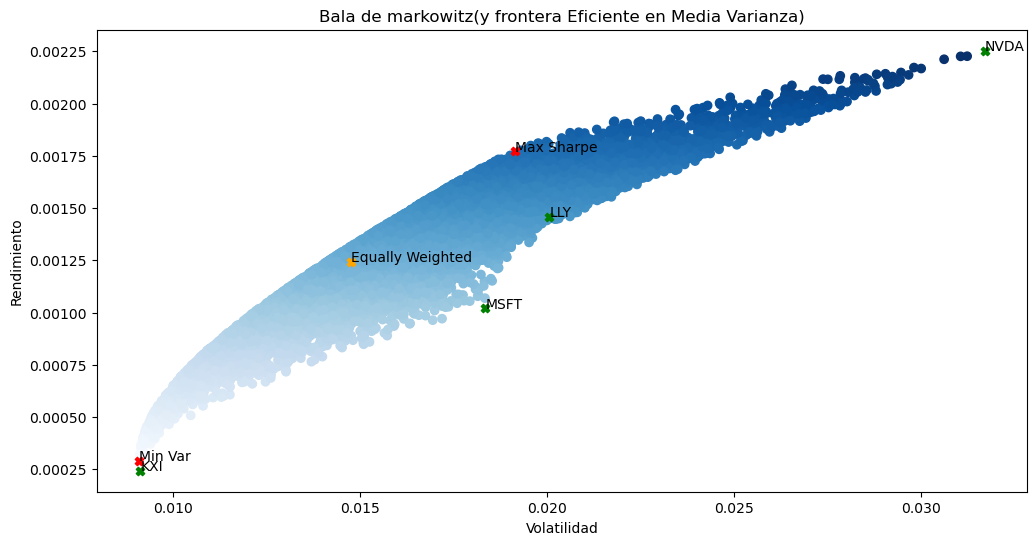

In [26]:
# Realizar grafica
plt.figure(figsize=(12,6))

# Scatter plot de portafolios aleatorios
plt.scatter(vol_aleatorio, rend_aleatorio,c=rend_aleatorio, cmap='Blues')

# Scatter plot de Minima Varianza
plt.scatter(vol_min_var, R_min_var, marker='X', color='red')
plt.text(vol_min_var,R_min_var,'Min Var')

# Scatter plot de Maximo de Sharpe
plt.scatter(vol_max_sharpe, R_max_sharpe, marker='X', color='red')
plt.text(vol_max_sharpe,R_max_sharpe,'Max Sharpe')

# Scatter plot Equally Weighted
plt.scatter(vol_equal, R_equal, marker='X', color='orange')
plt.text(vol_equal,R_equal,'Equally Weighted')

# Nombrar eje x, y, titulo
plt.xlabel("Volatilidad")
plt.ylabel("Rendimiento")
plt.title('Bala de markowitz(y frontera Eficiente en Media Varianza)')


# Graficar coordenadas de activos individuales
for i in range(n_assets):
    plt.scatter(std.iloc[i], mean.iloc[i], marker='X', color='green')
    plt.text(std.iloc[i], mean.iloc[i], prices.columns[i])

plt.show()

En la gráfica la parte de arriba de la bala es la frontera eficiente porque ahí están las combinaciones que dan el mayor rendimiento posible para cierto nivel de riesgo

El portafolio de mínima varianza aparece hasta la izquierda porque es el que tiene menos riesgo y máximo Sharpe queda más arriba pero también más a la derecha porque tiene más rendimiento y más volatilidad

Algo que me llamó la atención es que el equally weighted quedó prácticamente sobre la parte superior de la bala. Entonces para este periodo sí se ve bastante eficiente en términos de media-varianza

Aun así no puedo decir que sea el mejor en todo porque no tiene ni el menor riesgo ni el mayor Sharpe. Quedó como una opción intermedia bastante buena pero depende de qué esté buscando

## 6. COMPARACIÓN DE LOS PORTAFOLIOS

In [27]:
R_min_var_anual=R_min_var*252
vol_min_var_anual=vol_min_var*np.sqrt(252)

R_max_sharpe_anual=R_max_sharpe*252
vol_max_sharpe_anual=vol_max_sharpe*np.sqrt(252)

R_equal_anual=R_equal*252
vol_equal_anual=vol_equal*np.sqrt(252)

Sharpe_min_var=(R_min_var_anual-rf)/vol_min_var_anual
Sharpe_max=(R_max_sharpe_anual-rf)/vol_max_sharpe_anual
Sharpe_equal=(R_equal_anual-rf)/vol_equal_anual

In [28]:
comparacion=pd.DataFrame({
    'Rendimiento anual':[R_min_var_anual*100,R_max_sharpe_anual*100,R_equal_anual*100],
    'Volatilidad anual':[vol_min_var_anual*100,vol_max_sharpe_anual*100,vol_equal_anual*100],
    'Sharpe':[Sharpe_min_var,Sharpe_max,Sharpe_equal]
},index=['Mínima Varianza','Máximo Sharpe','Equally Weighted'])

comparacion

,Rendimiento anual,Volatilidad anual,Sharpe
Mínima Varianza,7.367375,14.418412,0.233547
Máximo Sharpe,44.648908,30.368694,1.338514
Equally Weighted,31.338147,23.420600,1.167269


In [29]:
pesos_comparacion=pd.DataFrame({
    'Mínima Varianza':w_min_var*100,
    'Máximo Sharpe':w_max_sharpe*100,
    'Equally Weighted':w_equal*100
},index=prices.columns)

pesos_comparacion

,Mínima Varianza,Máximo Sharpe,Equally Weighted
Ticker,,,
KXI,9.578029e+01,2.416741e-15,25.0
LLY,3.664817e+00,6.055587e+01,25.0
MSFT,5.548905e-01,2.349823e-19,25.0
NVDA,1.642964e-16,3.944413e+01,25.0


## CONCLUSIONES

**1. ¿Cuál de estos portafolios es superior en términos de riesgo?**  
En términos de riesgo el portafolio de mínima varianza fue el que tuvo el mejor resultado porque presentó la volatilidad anual más baja con 14.42%. El equally weighted tuvo una volatilidad de 23.42% y el de máximo Sharpe de 30.37%.  
Entonces si lo que busco es reducir el riesgo lo más posible me quedaría con mínima varianza. Aun así también hay que ver que fue el portafolio con menor rendimiento anual con 7.37%, entonces sí reduce bastante el riesgo pero también sacrifica mucho rendimiento.  
Aquí no sería correcto decir que por tener menor riesgo automáticamente es el mejor portafolio en general, más bien es el mejor si mi prioridad es tener la menor volatilidad posible.

**2. ¿Cuál de estos portafolios es superior en términos de riesgo y retorno?**  
Si veo riesgo y rendimiento al mismo tiempo el portafolio que tuvo el mejor resultado fue el de máximo Sharpe.  
Este portafolio tuvo un rendimiento anual de 44.65%, una volatilidad de 30.37% y un Sharpe de 1.34 que fue el más alto de los tres. El equally weighted también tuvo buenos resultados con un rendimiento de 31.34%, volatilidad de 23.42% y Sharpe de 1.17 mientras que mínima varianza tuvo un Sharpe de solamente 0.23.  
Entonces aunque máximo Sharpe tuvo la volatilidad más alta, también fue el que mejor compensó el riesgo con el rendimiento que generó. Por eso si mi objetivo fuera buscar una mejor relación entre riesgo y rendimiento este sería el que tendría más sentido.

**3. Interpreta la frontera eficiente en base a la teoría vista en clase y responde ¿Qué pasa con el portafolio equally weighted? ¿Es óptimo? ¿Por qué?**  
La frontera eficiente representa los portafolios que para cierto nivel de riesgo ofrecen el mayor rendimiento posible. Si un portafolio queda por debajo de esta frontera quiere decir que existe otra combinación que podría dar un mayor rendimiento tomando prácticamente el mismo nivel de riesgo.  
En mi gráfica el portafolio equally weighted quedó prácticamente sobre la parte superior de la bala de Markowitz, entonces para el periodo que analicé se ve como una combinación bastante eficiente en términos de media-varianza.  
Esto me pareció interesante porque este portafolio simplemente tiene 25% en cada activo y no fue optimizado usando mínima varianza ni máximo Sharpe. Aun así tuvo un rendimiento anual de 31.34% con una volatilidad de 23.42%.  
Entonces sí puedo decir que quedó muy cerca de ser óptimo en términos de media-varianza para este periodo. Aun así no significa que sea el mejor portafolio en todos los sentidos porque mínima varianza sigue teniendo menos riesgo y máximo Sharpe tiene una mejor relación entre riesgo y rendimiento.

**4. ¿Por qué un portafolio podría ser mejor que otro? ¿De qué depende que sea "mejor"?**  
Para mí que un portafolio sea mejor que otro depende principalmente de qué busca la inversionista y de cuánto riesgo está dispuesta a aceptar.  
Por ejemplo si una persona busca tener menos movimientos en su inversión y su prioridad es reducir el riesgo probablemente tendría más sentido mínima varianza. En cambio si está dispuesta a aceptar más volatilidad a cambio de buscar una mejor relación entre riesgo y rendimiento sería más atractivo máximo Sharpe.  
El equally weighted también puede ser una opción para alguien que busca una distribución más sencilla donde ningún activo tenga una concentración demasiado alta.  
Entonces no existe un solo portafolio que sea el mejor para todos. Depende de si busco principalmente menor riesgo, mayor rendimiento, una mejor relación riesgo rendimiento o una distribución más equilibrada del capital.

**5. Analiza las ponderaciones obtenidas por el método de mínima varianza y el de máximo de Sharpe para cada activo de manera individual ¿Qué factores explican que cada activo tenga una mayor o menor ponderación en uno de los métodos en comparación con el otro?**  
En el portafolio de mínima varianza casi todo el peso se concentró en KXI con 95.78%. Después quedó LLY con 3.66%, MSFT con 0.55% y NVDA prácticamente con 0%.  
En KXI esto tiene bastante sentido porque fue el activo con menor volatilidad individual con 14.46%. Además al ser un ETF de consumo básico está expuesto a factores diferentes a los de las empresas de tecnología y salud, lo que puede ayudar a la diversificación del portafolio aunque esto no significa que sus movimientos sean independientes. Como aquí el objetivo es reducir el riesgo lo más posible KXI termina teniendo casi todo el peso porque aporta mucha más estabilidad al portafolio.  
LLY tuvo un rendimiento anual de 36.76% y una volatilidad de 31.84%. Aunque es bastante más volátil que KXI todavía recibió 3.66%, lo que indica que dentro de la combinación sigue ayudando un poco al portafolio tomando en cuenta también cómo se mueve con los demás activos.  
MSFT tuvo un rendimiento anual de 25.69% y una volatilidad de 29.12% pero recibió solamente 0.55%. Esto no quiere decir que sea un mal activo, simplemente dentro de estos cuatro activos no ayuda tanto a reducir la varianza del portafolio como lo hace KXI.  
Por último NVDA quedó prácticamente en 0% en mínima varianza. Aunque fue el activo con mayor rendimiento anual con 56.77%, también tuvo por mucho la mayor volatilidad con 50.33%. Como aquí lo que quiero es minimizar el riesgo darle más peso a NVDA aumentaría demasiado la volatilidad total.

En máximo Sharpe prácticamente pasó lo contrario. LLY recibió 60.56% y NVDA 39.44% mientras que KXI y MSFT quedaron prácticamente en 0%.  
Aquí ya no estoy buscando solamente bajar el riesgo sino encontrar la combinación con la mejor relación entre rendimiento y riesgo. LLY y NVDA fueron justamente los activos con mayores rendimientos del periodo con 36.76% y 56.77%, entonces aunque tienen más volatilidad también aportan mucho más rendimiento y por eso recibieron las ponderaciones más altas.  
KXI quedó fuera porque aunque tuvo la menor volatilidad también tuvo un rendimiento anual de solamente 6.14%, entonces funciona muy bien para reducir riesgo pero no aporta suficiente rendimiento cuando lo que quiero es maximizar el Sharpe.  
MSFT también quedó prácticamente en 0% aunque tuvo un rendimiento de 25.69% y una volatilidad de 29.12%. Esto no significa que Microsoft sea una mala inversión, simplemente dentro de estos cuatro activos y con los datos del periodo que analicé la combinación de LLY y NVDA fue mejor para maximizar la relación entre riesgo y rendimiento.  
También es importante recordar que las ponderaciones no dependen solamente del rendimiento y la volatilidad de cada activo individualmente. La optimización también toma en cuenta la covarianza entre ellos, o sea cómo se mueven los rendimientos de unos activos en relación con los otros.  
Y aunque tener activos de distintos sectores ayuda a diversificar esto no significa que siempre se vayan a mover de forma independiente. La diversificación ayuda principalmente a reducir el riesgo no sistemático pero el riesgo sistemático que afecta al mercado completo no se puede eliminar solamente diversificando.

**6. Concluye acerca de las ventajas y desventajas de una estrategia cuantitativa de asignación de activos frente a una basada en "feeling" o intuición.**  
Para mí una de las principales ventajas de usar una estrategia cuantitativa es que las decisiones se toman usando datos y una metodología clara. En este caso las ponderaciones no se escogieron solamente porque una empresa me gusta o porque siento que una acción va a subir, sino que utilicé los rendimientos, volatilidades y covarianzas para decidir cuánto peso darle a cada activo dependiendo del objetivo.  
También ayuda a reducir algunos sesgos porque puedo comparar las estrategias con métricas y no solamente con mi opinión. Por ejemplo en mis resultados se ve claramente que mínima varianza funciona mejor si quiero reducir el riesgo mientras que máximo Sharpe funciona mejor si busco una mejor relación entre riesgo y rendimiento.  
La principal desventaja es que todo esto está basado en información histórica. Que estos activos hayan tenido determinados rendimientos, volatilidades y relaciones durante este periodo no significa que se vayan a comportar exactamente igual en el futuro.  
Además una estrategia solamente cuantitativa puede dejar fuera información importante sobre las empresas, sus sectores o lo que esté pasando actualmente en el mercado.  
Por eso para mí lo mejor sería utilizar el análisis cuantitativo como una base para tomar decisiones y complementarlo con un análisis de las empresas y del entorno financiero. Así evito depender solamente del feeling pero tampoco tomo una decisión únicamente porque un modelo basado en datos históricos me dio cierto resultado.